# Part 11: Backtesting a New Factor (Main)



In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from statsmodels.api import OLS

import warnings
warnings.filterwarnings("ignore")

from simple_factor_process import FactorProcessing_CorrelationBetweenTwoFactors as FactorIC # 因子IC
from simple_factor_process import FactorTool_GetStockSplit as FactorGroup # 分组
from simple_factor_process import FactorPurify # 中性化

from 一级二级行业字典 import dict_I,dict_II


# stock data
sw_ind = pd.read_pickle('数据/IndexComponent_SWN_I.txt')
stock_close = pd.read_pickle('数据/StockQuote_ClosePrice_BackwardAdj.txt')
stock_open = pd.read_pickle('数据/StockQuote_OpenPrice_BackwardAdj.txt')
monthly_trading_day = pd.read_pickle('数据/monthly_trading_day.pkl')
monthly_trading_day['start_date'] = pd.to_datetime(monthly_trading_day['start_date'], format='%Y%m%d')
monthly_trading_day['end_date'] = pd.to_datetime(monthly_trading_day['end_date'], format='%Y%m%d')
start_date = pd.to_datetime('20120101', format='%Y%m%d')
end_date = pd.to_datetime('20231231', format='%Y%m%d')
filtered_trading_days = monthly_trading_day.loc[(monthly_trading_day['end_date'] >= start_date) & (monthly_trading_day['end_date'] <= end_date)]
stock_close.index = pd.to_datetime(stock_close.index)
stock_open.index = pd.to_datetime(stock_open.index)
stock_ret_monthly = stock_close.reindex(index = filtered_trading_days.end_date).pct_change() 
stock_ret_monthly_nextopen = stock_open.shift(-1).reindex(filtered_trading_days.end_date).pct_change()

# index data
index_relative_price = pd.read_pickle('IndexQuote_SWS_ClosePrice.txt')
index_relative_price_1 = index_relative_price[list(dict_I.keys())]
index_relative_price_2 = index_relative_price[list(dict_II.keys())]

index_relative_price.index = pd.to_datetime(index_relative_price.index)
index_relative_ret_monthly = index_relative_price.reindex(index = filtered_trading_days.end_date).pct_change()
index_relative_ret_monthly_nextopen = index_relative_price.shift(-1).reindex(filtered_trading_days.end_date).pct_change()

index_relative_price_1.index = pd.to_datetime(index_relative_price_1.index)
index_relative_ret_monthly_1 = index_relative_price_1.reindex(index = filtered_trading_days.end_date).pct_change()
index_relative_ret_monthly_nextopen_1 = index_relative_price_1.shift(-1).reindex(filtered_trading_days.end_date).pct_change()

index_relative_price_2.index = pd.to_datetime(index_relative_price_2.index)
index_relative_ret_monthly_2 = index_relative_price_2.reindex(index = filtered_trading_days.end_date).pct_change()
index_relative_ret_monthly_nextopen_2 = index_relative_price_2.shift(-1).reindex(filtered_trading_days.end_date).pct_change()

index_daily_return = index_relative_price.pct_change()
index_daily_return = index_daily_return.loc['20120101':'20231231', :]
index_daily_return.index = pd.to_datetime(index_daily_return.index)

index_daily_return_1 = index_relative_price_1.pct_change()
index_daily_return_1 = index_daily_return_1.loc['20120101':'20231231', :]
index_daily_return_1.index = pd.to_datetime(index_daily_return_1.index)

index_daily_return_2 = index_relative_price_2.pct_change()
index_daily_return_2 = index_daily_return_2.loc['20120101':'20231231', :]
index_daily_return_2.index = pd.to_datetime(index_daily_return_2.index)


def simple_factor_test(factor, use_data = 'this_close'):
    if use_data=='this_close':
        this_ret_data = index_relative_ret_monthly_2.shift(-1)
    else: 
        this_ret_data = index_relative_ret_monthly_nextopen_2.shift(-1)
    ic,rankic = FactorIC(factor,this_ret_data) # 计算因子的ic,rankic序列
    factor_group = FactorGroup(factor)
    condata = pd.concat([factor_group.unstack(),this_ret_data.unstack()],axis=1).dropna().reset_index()
    condata.columns =['stockcode','date','group_id','ret']
    group_ret = condata.groupby(['date','group_id'])['ret'].mean().unstack()
    return ic,rankic,group_ret,factor_group

In [5]:
# 构建方法：涨跌停的比列
ZT = (stock_close - stock_open) / stock_open 
number_of_stocks = ZT.T.count()
ZT = abs(ZT) >= 0.09 
number_of_stocks_toomuch = ZT.T.sum()
factor = number_of_stocks_toomuch / number_of_stocks
factor.replace(np.nan, 0, inplace = True) 
# select 2012 - 2023
factor = factor.loc['20120101':'20231231']
factor.index = pd.to_datetime(factor.index)
famafrench = pd.read_excel("STK_MKT_THRFACDAY.xlsx")
famafrench = famafrench[famafrench['MarkettypeID'] == "P9706"]
famafrench = famafrench.reset_index(drop= True)
famafrench = famafrench.set_index("TradingDate").loc["2012-01-01" : '2023-12-31'][['RiskPremium2', "SMB2", "HML2"]]
fourfactors = pd.merge(pd.DataFrame(factor).reset_index(), famafrench.reset_index() , left_index=True, right_index=True, how='left')
fourfactors.columns = ["Tradingdays","APL", "TradingDate", "RiskPremium2", "SMB2", "HML2"]
fourfactors_reordered = fourfactors[[ 'TradingDate','APL', 'RiskPremium2', 'SMB2', 'HML2']]
fourfactors_reordered ['TradingDate'] = pd.to_datetime(fourfactors_reordered ['TradingDate'])
fourfactors_reordered = fourfactors_reordered.set_index('TradingDate')
fourfactors_reordered

,APL,RiskPremium2,SMB2,HML2
TradingDate,,,,
2012-01-04,0.011760,-0.016205,-0.004502,0.00939
2012-01-05,0.027439,-0.013403,-0.027523,0.01463
2012-01-06,0.005220,0.00707,-0.002101,0.000992
2012-01-09,0.028273,0.030277,0.008748,-0.010063
2012-01-10,0.026945,0.028804,0.006326,-0.014061
...,...,...,...,...
2023-12-25,0.013508,0.00202,-0.00887,-0.001847
2023-12-26,0.010692,-0.005552,-0.005357,0.004727
2023-12-27,0.008815,0.0064,0.002296,0.002342


In [80]:
all_results = {}

for stock in index_daily_return_2.columns:
    Y = index_daily_return[stock]
    X = fourfactors_reordered
    X['RiskPremium2'] = pd.to_numeric(X['RiskPremium2'], errors='coerce')
    X['SMB2'] = pd.to_numeric(X['SMB2'], errors='coerce')
    X['HML2'] = pd.to_numeric(X['HML2'], errors='coerce')

    # match the index of X and Y
    Y = Y.loc[X.index]
    # print(Y)
    # print(X)
    
    stock_results = {}

    for index, row in filtered_trading_days.iterrows():
        
        start_date = pd.to_datetime(row['start_date'], format='%Y%m%d')
        end_date = pd.to_datetime(row['end_date'], format='%Y%m%d')
        X_subset = X.loc[(X.index >= start_date) & (X.index <= end_date)]
        Y_subset = Y.loc[(Y.index >= start_date) & (Y.index <= end_date)]

        if len(X_subset) == len(Y_subset) and len(X_subset) > 0:

            # handle missing values
            X_subset = X_subset.dropna()
            Y_subset = Y_subset.loc[X_subset.index]

            X_subset = X_subset.reset_index(drop=True)
            Y_subset = Y_subset.reset_index(drop=True)

            # Add a constant for the regression intercept
            X_with_const = sm.add_constant(X_subset, has_constant='add')
            

            # Run the regression
            model = sm.OLS(Y_subset, X_with_const)
            regression_results = model.fit()

            # Store the regression results for this month
            stock_results[end_date] = regression_results.params

        else:
            print('No data for stock {} for the period from {} to {}'.format(stock, start_date, end_date))
            stock_results[end_date] = np.nan

    # Store the results for the current stock
        all_results[stock] = stock_results
    # break

# Convert all_results to a DataFrame for a clean and organized output
all_params = {(outerKey, innerKey): values for outerKey, innerDict in all_results.items() for innerKey, values in innerDict.items()}
param_df = pd.DataFrame(all_params).T
param_df.index.names = ['Stock', 'End_Date']

# Display the organized results
print(param_df)


                         const       APL  RiskPremium2      SMB2      HML2
Stock     End_Date                                                        
801103.SI 2012-01-31 -0.001986 -0.120881      1.014332  0.901484 -0.995141
          2012-02-29 -0.002185  0.548514      0.941378  0.958170 -0.116992
          2012-03-30  0.002499 -0.512156      1.032181  0.521626 -0.536827
          2012-04-27  0.004704 -0.699003      1.246475  0.306871 -0.733412
          2012-05-31  0.002175 -0.568248      0.952736  0.406586 -0.847790
...                        ...       ...           ...       ...       ...
801231.SI 2023-07-31 -0.000511  0.043031      1.232103  1.031307  0.313580
          2023-08-31 -0.003881  0.170117      0.822569  0.713405  0.329963
          2023-09-28  0.000310 -0.046120      1.052892  0.984785  0.147850
          2023-10-31 -0.004812  0.460091      1.107380  0.706413 -0.306168
          2023-11-30 -0.001532 -0.008479      0.674655  1.010479  0.435194

[17875 rows x 5 columns]

In [ ]:
all_results = {}

for stock in index_daily_return_2.columns:
    Y = index_daily_return[stock]
    X = fourfactors_reordered
    X['RiskPremium2'] = pd.to_numeric(X['RiskPremium2'], errors='coerce')
    X['SMB2'] = pd.to_numeric(X['SMB2'], errors='coerce')
    X['HML2'] = pd.to_numeric(X['HML2'], errors='coerce')

    # match the index of X and Y
    Y = Y.loc[X.index]
    # print(Y)
    # print(X)
    
    stock_results = {}

    for index, row in filtered_trading_days.iterrows():
        
        start_date = pd.to_datetime(row['start_date'], format='%Y%m%d')
        end_date = pd.to_datetime(row['end_date'], format='%Y%m%d')
        X_subset = X.loc[(X.index >= start_date) & (X.index <= end_date)]
        Y_subset = Y.loc[(Y.index >= start_date) & (Y.index <= end_date)]

        if len(X_subset) == len(Y_subset) and len(X_subset) > 0:

            # handle missing values
            X_subset = X_subset.dropna()
            Y_subset = Y_subset.loc[X_subset.index]

            X_subset = X_subset.reset_index(drop=True)
            Y_subset = Y_subset.reset_index(drop=True)

            # Add a constant for the regression intercept
            X_with_const = sm.add_constant(X_subset, has_constant='add')
            

            # Run the regression
            model = sm.OLS(Y_subset, X_with_const)
            regression_results = model.fit()

            # Store the regression results for this month
            stock_results[end_date] = regression_results.params

        else:
            print('No data for stock {} for the period from {} to {}'.format(stock, start_date, end_date))
            stock_results[end_date] = np.nan

    # Store the results for the current stock
        all_results[stock] = stock_results
    # break

# Convert all_results to a DataFrame for a clean and organized output
all_params = {(outerKey, innerKey): values for outerKey, innerDict in all_results.items() for innerKey, values in innerDict.items()}
param_df = pd.DataFrame(all_params).T
param_df.index.names = ['Stock', 'End_Date']

# Display the organized results
print(param_df)


                         const       APL  RiskPremium2      SMB2      HML2
Stock     End_Date                                                        
801103.SI 2012-01-31 -0.001986 -0.120881      1.014332  0.901484 -0.995141
          2012-02-29 -0.002185  0.548514      0.941378  0.958170 -0.116992
          2012-03-30  0.002499 -0.512156      1.032181  0.521626 -0.536827
          2012-04-27  0.004704 -0.699003      1.246475  0.306871 -0.733412
          2012-05-31  0.002175 -0.568248      0.952736  0.406586 -0.847790
...                        ...       ...           ...       ...       ...
801231.SI 2023-07-31 -0.000511  0.043031      1.232103  1.031307  0.313580
          2023-08-31 -0.003881  0.170117      0.822569  0.713405  0.329963
          2023-09-28  0.000310 -0.046120      1.052892  0.984785  0.147850
          2023-10-31 -0.004812  0.460091      1.107380  0.706413 -0.306168
          2023-11-30 -0.001532 -0.008479      0.674655  1.010479  0.435194

[17875 rows x 5 columns]

In [87]:
pivoted_df = param_df["APL"].unstack().T
pivoted_df.index = pd.to_datetime(pivoted_df.index)
pivoted_df_monthly = pivoted_df.reindex(index = filtered_trading_days.end_date) # 按月抽样得到因子值
pivoted_df_monthly

Stock,801011.SI,801012.SI,801014.SI,801015.SI,801016.SI,801017.SI,801018.SI,801032.SI,801033.SI,801034.SI,...,801963.SI,801971.SI,801972.SI,801981.SI,801982.SI,801991.SI,801992.SI,801993.SI,801994.SI,801995.SI
end_date,,,,,,,,,,,,,,,,,,,,,
2012-01-31,-0.057293,-0.111125,0.260336,-0.158474,0.154346,-0.460253,-0.152612,0.094090,0.211840,0.150571,...,0.108725,-0.369006,-0.696952,0.087872,-0.319439,-0.026607,0.453492,0.031227,0.091212,0.262938
2012-02-29,1.152685,0.291386,1.576828,1.302202,0.987070,2.280960,3.994884,-0.109904,-0.300930,-0.304030,...,0.209972,1.186287,3.385000,1.438891,-0.493251,1.088008,1.181919,-0.621578,1.379552,2.066608
2012-03-30,-1.036407,0.139173,-0.445822,0.270096,0.310931,2.270418,-1.235194,-0.112817,-0.073473,-0.018982,...,-0.044676,0.153550,-0.330294,-0.168197,0.685623,0.107446,-0.167216,0.374489,-1.236944,-1.319034
2012-04-27,-0.414840,-0.707737,0.315241,0.572732,-0.496861,0.115952,0.022734,-0.045580,-0.720031,-0.284440,...,-0.027832,-0.329797,0.151103,1.652524,-0.632058,0.200661,0.010179,0.185460,-0.477711,-3.594758
2012-05-31,2.356564,-0.581562,-1.636874,0.488822,-0.003942,0.113706,-0.550491,0.735251,0.074046,-0.597309,...,-0.868198,0.140891,-0.353971,-0.988980,-0.015298,0.406463,2.225258,-0.283864,-1.693536,-0.774486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-31,0.000000,0.116723,0.920060,1.826660,2.099809,0.691583,0.365633,0.409984,-0.374451,-0.894768,...,-0.026695,-0.285859,0.495970,0.896281,0.402757,0.778601,0.985643,0.005262,-0.476553,-0.984885
2023-08-31,0.000000,0.402728,0.187957,0.769582,0.043289,0.018158,0.177803,-0.185794,-0.010602,0.178533,...,-0.102523,0.173672,0.226590,0.390216,0.123619,-0.076994,-0.087576,0.162272,-0.092773,0.274774
2023-09-28,0.000000,-0.195765,-0.195302,-3.983386,-0.492763,0.012630,-0.762447,0.594352,-0.989705,0.628240,...,0.104380,-1.113737,0.068565,-0.677031,-0.416096,-1.674872,-2.581712,0.977006,0.204019,1.462030


In [88]:
# change its columns by matching the keys and items in the dictionary
# pivoted_df_monthly.columns = [dict_II[i] for i in pivoted_df_monthly.columns]
# pivoted_df_monthly

In [90]:
ic,rankic,group_ret,factor_group  = simple_factor_test(pivoted_df_monthly)

In [94]:
rank_ic_mean = ic.mean()
rank_ic_std = ic.std()
rank_icir = rank_ic_mean / rank_ic_std if rank_ic_std != 0 else float('nan')
ic_win_rate = (ic > 0).mean()

print(f"Rank IC Mean: {rank_ic_mean:.4f}")
print(f"Rank ICIR: {rank_icir:.4f}")
print(f"IC Win Rate: {ic_win_rate:.2%}")


Rank IC Mean: 0.0164
Rank ICIR: 0.1085
IC Win Rate: 55.24%


In [91]:
group_ret


group_id,0.0,1.0,2.0,3.0,4.0
date,,,,,
2012-01-31,0.112787,0.117517,0.104578,0.110316,0.085553
2012-02-29,-0.058678,-0.072316,-0.071968,-0.066868,-0.054874
2012-03-30,0.061474,0.036438,0.071900,0.052278,0.041378
2012-04-27,0.020095,0.019490,0.018842,0.010855,-0.006998
2012-05-31,-0.033168,-0.059847,-0.057866,-0.060415,-0.074623
...,...,...,...,...,...
2023-06-30,-0.000792,0.029523,0.025570,0.047031,0.014425
2023-07-31,-0.047150,-0.050442,-0.062422,-0.065583,-0.054466
2023-08-31,-0.014060,-0.005558,-0.001723,-0.000222,-0.020139


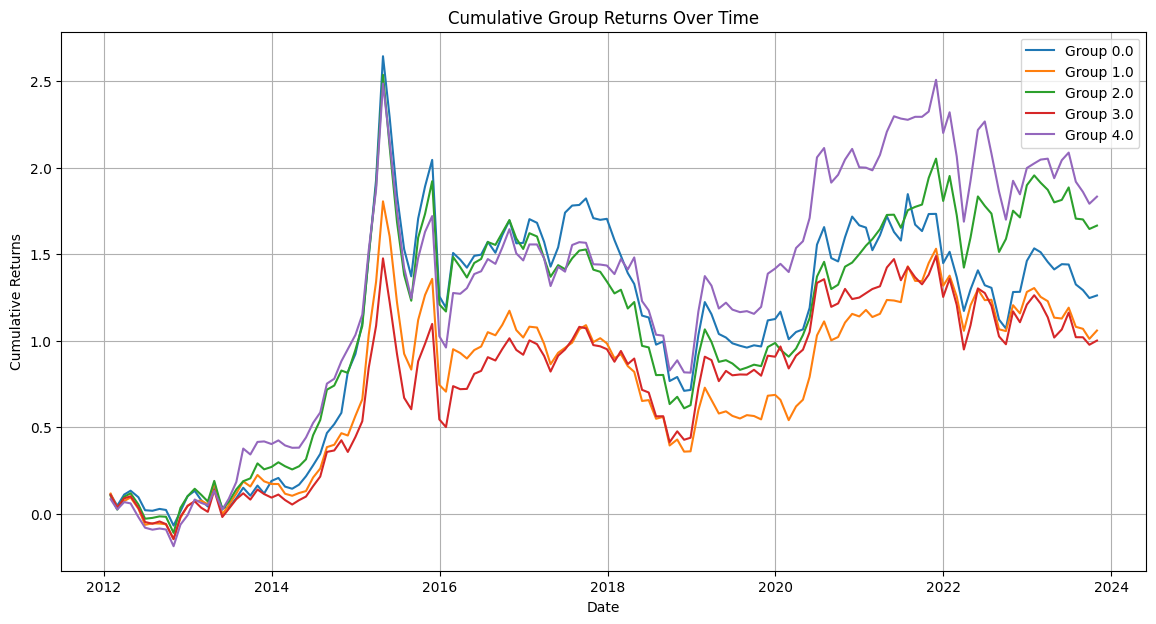

In [92]:
cumulative_returns = (1 + group_ret).cumprod() - 1

# 绘制累积收益率
plt.figure(figsize=(14, 7))
for column in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[column], label=f'Group {column}')

plt.title('Cumulative Group Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()
